# Análisis exploratorio y limpieza de datos: Home Credit Default Risk

Proyecto de Ética y Seguridad de Datos (DS3031), CrediFácil

Este documento presenta el análisis exploratorio (EDA) y el proceso de limpieza aplicado a las dos tablas del dataset Home Credit Default Risk que se utilizan en el proyecto: application_train.csv, que contiene las solicitudes de crédito y la variable objetivo, y bureau.csv, que contiene el historial crediticio de los clientes en otras entidades financieras.

El documento se divide en dos partes. En la primera se explora la estructura de los datos, su calidad y las relaciones relevantes para el caso de negocio. En la segunda se aplican las transformaciones que los hallazgos del EDA justifican, y se generan los archivos que alimentarán el pipeline hacia la base de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = "../home-credit-default-risk/"
train = pd.read_csv(DATA_DIR + "application_train.csv")
bureau = pd.read_csv(DATA_DIR + "bureau.csv")

print("application_train:", train.shape)
print("bureau:", bureau.shape)

application_train: (307511, 122)
bureau: (1716428, 17)


## Parte 1: Análisis exploratorio de datos

### 1.1 Estructura general

application_train contiene 307,511 solicitudes y 122 variables, incluyendo la variable objetivo TARGET. A continuación se revisa la composición de tipos de datos y el uso de memoria.

In [2]:
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,...,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,...,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,...,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
train.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 536.7 MB


In [4]:
train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

De las 122 columnas, la mayoría son numéricas (int64/float64) y 16 son categóricas (object). No se observan duplicados en el identificador del cliente, lo cual se confirma a continuación.

In [5]:
print("SK_ID_CURR duplicados:", train["SK_ID_CURR"].duplicated().sum())

SK_ID_CURR duplicados: 0


### 1.2 Valores faltantes

Se calcula el porcentaje de valores nulos por columna para identificar qué variables requieren tratamiento antes de usarse en el modelo.

Columnas con algún valor nulo: 67 de 122


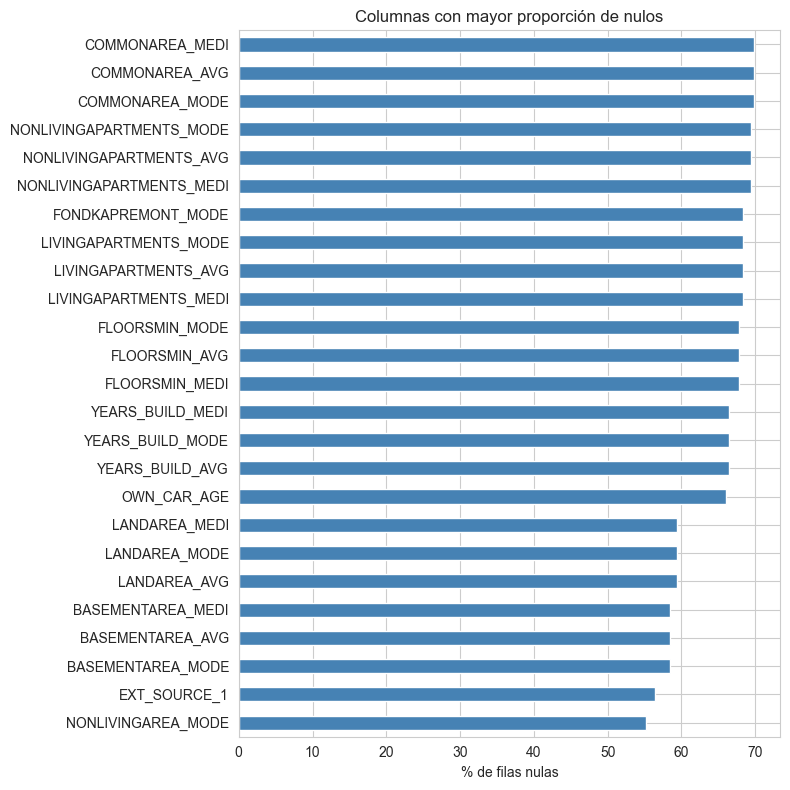

In [6]:
nulls = train.isnull().mean().sort_values(ascending=False) * 100
nulls = nulls[nulls > 0]
print(f"Columnas con algún valor nulo: {len(nulls)} de {train.shape[1]}")

fig, ax = plt.subplots(figsize=(8, 8))
nulls.head(25).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de filas nulas")
ax.set_title("Columnas con mayor proporción de nulos")
plt.tight_layout()
plt.show()

In [7]:
nulls.head(25).round(1)

COMMONAREA_MEDI             69.9
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
NONLIVINGAPARTMENTS_MEDI    69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_MODE       68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
FLOORSMIN_AVG               67.8
FLOORSMIN_MODE              67.8
FLOORSMIN_MEDI              67.8
YEARS_BUILD_MEDI            66.5
YEARS_BUILD_MODE            66.5
YEARS_BUILD_AVG             66.5
OWN_CAR_AGE                 66.0
LANDAREA_MEDI               59.4
LANDAREA_MODE               59.4
LANDAREA_AVG                59.4
BASEMENTAREA_MEDI           58.5
BASEMENTAREA_AVG            58.5
BASEMENTAREA_MODE           58.5
EXT_SOURCE_1                56.4
NONLIVINGAREA_MODE          55.2
dtype: float64

Las columnas con mayor proporción de nulos (entre 55% y 70%) corresponden casi en su totalidad a variables descriptivas del edificio donde reside el cliente (APARTMENTS_*, COMMONAREA_*, LIVINGAREA_*, entre otras). Estas variables son secundarias para el caso de negocio planteado y se descartarán en la etapa de limpieza.

Una excepción relevante es EXT_SOURCE_1, con 56.4% de valores nulos, ya que corresponde a una de las variables con mayor poder predictivo del dataset (sección 1.8).

El resto de columnas con nulos, fuera del bloque del edificio, queda fuera del gráfico anterior por tener una proporción menor. Se revisan a continuación, ya que varias sí requieren tratamiento antes de usarse en el modelo.

In [8]:
building_cols = [c for c in train.columns if c.endswith(("_AVG", "_MODE", "_MEDI"))]
building_cols += ["FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "TOTALAREA_MODE",
                   "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"]
building_cols = set(building_cols)

resto_nulos = nulls[~nulls.index.isin(building_cols)]
resto_nulos.round(2)

OWN_CAR_AGE                   65.99
EXT_SOURCE_1                  56.38
OCCUPATION_TYPE               31.35
EXT_SOURCE_3                  19.83
AMT_REQ_CREDIT_BUREAU_HOUR    13.50
AMT_REQ_CREDIT_BUREAU_DAY     13.50
AMT_REQ_CREDIT_BUREAU_WEEK    13.50
AMT_REQ_CREDIT_BUREAU_MON     13.50
AMT_REQ_CREDIT_BUREAU_QRT     13.50
AMT_REQ_CREDIT_BUREAU_YEAR    13.50
NAME_TYPE_SUITE                0.42
OBS_30_CNT_SOCIAL_CIRCLE       0.33
DEF_30_CNT_SOCIAL_CIRCLE       0.33
OBS_60_CNT_SOCIAL_CIRCLE       0.33
DEF_60_CNT_SOCIAL_CIRCLE       0.33
EXT_SOURCE_2                   0.21
AMT_GOODS_PRICE                0.09
AMT_ANNUITY                    0.00
CNT_FAM_MEMBERS                0.00
DAYS_LAST_PHONE_CHANGE         0.00
dtype: float64

Entre estas, OCCUPATION_TYPE destaca con 31.4% de nulos y no forma parte del bloque del edificio, por lo que requiere una decisión explícita de tratamiento. Las seis variables AMT_REQ_CREDIT_BUREAU_* comparten un 13.5% de nulos cada una, lo que sugiere que faltan de forma conjunta en las mismas filas (probablemente clientes sin consultas registradas al buró). OWN_CAR_AGE mantiene un 66% de nulos, coherente con clientes que no poseen automóvil. El resto de columnas tiene una proporción de nulos menor a 1%.

Adicionalmente, se revisan las variables binarias/flag del dataset (FLAG_OWN_CAR, FLAG_OWN_REALTY, FLAG_MOBIL, FLAG_EMP_PHONE, FLAG_DOCUMENT_2 a FLAG_DOCUMENT_21, y los flags de coincidencia de dirección REG_REGION_NOT_LIVE_REGION y similares), que no aparecen en los listados anteriores por no tener valores nulos.

In [9]:
flag_cols = [c for c in train.columns if c.startswith("FLAG_")]
flag_cols += ["REG_REGION_NOT_LIVE_REGION", "REG_REGION_NOT_WORK_REGION", "LIVE_REGION_NOT_WORK_REGION",
              "REG_CITY_NOT_LIVE_CITY", "REG_CITY_NOT_WORK_CITY", "LIVE_CITY_NOT_WORK_CITY"]

resumen_flags = pd.DataFrame({
    "nulos": train[flag_cols].isnull().sum(),
    "valores_unicos": [sorted(train[c].dropna().unique().tolist(), key=str) for c in flag_cols],
    "proporcion_valor_mayoritario": train[flag_cols].apply(lambda s: s.value_counts(normalize=True).max())
})
resumen_flags.sort_values("proporcion_valor_mayoritario", ascending=False).round(4)

,nulos,valores_unicos,proporcion_valor_mayoritario
FLAG_MOBIL,0,"[0, 1]",1.0000
FLAG_DOCUMENT_12,0,"[0, 1]",1.0000
FLAG_DOCUMENT_10,0,"[0, 1]",1.0000
FLAG_DOCUMENT_2,0,"[0, 1]",1.0000
FLAG_DOCUMENT_4,0,"[0, 1]",0.9999
FLAG_DOCUMENT_7,0,"[0, 1]",0.9998
FLAG_DOCUMENT_17,0,"[0, 1]",0.9997
FLAG_DOCUMENT_21,0,"[0, 1]",0.9997
FLAG_DOCUMENT_20,0,"[0, 1]",0.9995
FLAG_DOCUMENT_19,0,"[0, 1]",0.9994


Las 34 columnas de tipo flag/binario no presentan valores nulos ni categorías fuera de las esperadas (0/1 o Y/N), por lo que no requieren limpieza. Se observa, sin embargo, que varias de ellas son casi constantes: FLAG_MOBIL tiene el mismo valor en 307,510 de 307,511 registros, y ocho de las variables FLAG_DOCUMENT_* superan el 99.9% de concentración en un solo valor. Esto no es un problema de calidad de datos, sino de utilidad para el modelo: una variable casi constante aporta poca capacidad de discriminación entre clases. Se documenta como criterio a evaluar en la etapa de selección de variables del modelo, no se descarta en esta etapa de limpieza.

### 1.3 Distribución de la variable objetivo

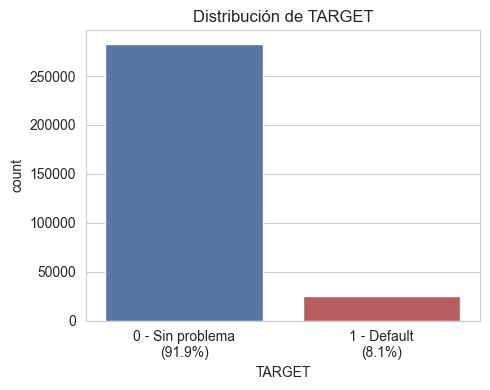

TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [10]:
target_pct = train["TARGET"].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"0 - Sin problema\n({target_pct[0]:.1f}%)", f"1 - Default\n({target_pct[1]:.1f}%)"])
ax.set_title("Distribución de TARGET")
plt.tight_layout()
plt.show()

print(target_pct.round(2))

El dataset presenta un desbalance de clases considerable: 91.9% de las solicitudes no presentaron problemas de pago, frente a 8.1% que sí. Este desbalance debe considerarse al entrenar el modelo de scoring, ya que una métrica como el accuracy resultaría engañosa: un clasificador que prediga siempre "no default" alcanzaría 91.9% de accuracy sin capturar ningún caso de riesgo real. Se recomienda evaluar el modelo con AUC-ROC y ajustar el peso de las clases durante el entrenamiento.

### 1.4 Variables numéricas asociadas al crédito y al perfil del cliente

In [11]:
cols_negocio = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE", "DAYS_BIRTH", "DAYS_EMPLOYED"]
train[cols_negocio].describe().round(1)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_EMPLOYED
count,307511.0,307511.0,307499.0,307233.0,307511.0,307511.0
mean,168797.9,599026.0,27108.6,538396.2,-16037.0,63815.0
std,237123.1,402490.8,14493.7,369446.5,4364.0,141275.8
min,25650.0,45000.0,1615.5,40500.0,-25229.0,-17912.0
25%,112500.0,270000.0,16524.0,238500.0,-19682.0,-2760.0
50%,147150.0,513531.0,24903.0,450000.0,-15750.0,-1213.0
75%,202500.0,808650.0,34596.0,679500.0,-12413.0,-289.0
max,117000000.0,4050000.0,258025.5,4050000.0,-7489.0,365243.0


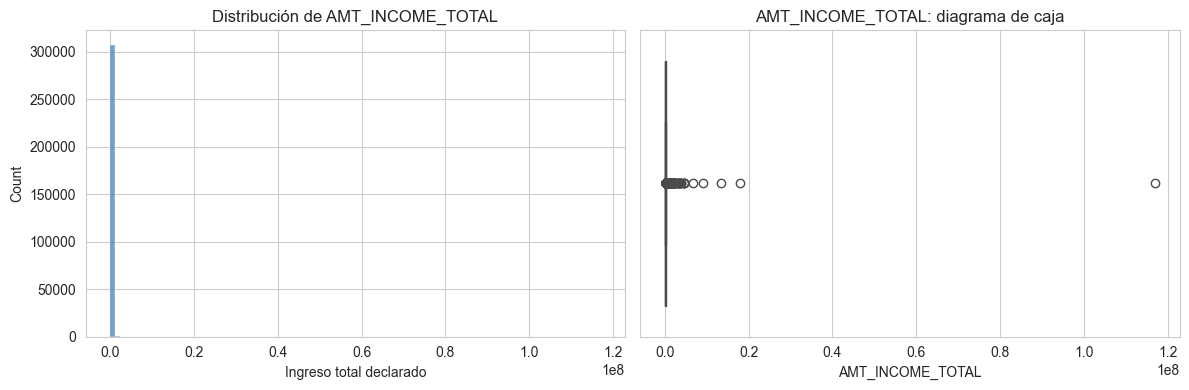

Percentil 75: 202500.0
Percentil 99: 472500.0
Máximo: 117000000.0


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["AMT_INCOME_TOTAL"], bins=100, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de AMT_INCOME_TOTAL")
axes[0].set_xlabel("Ingreso total declarado")

sns.boxplot(x=train["AMT_INCOME_TOTAL"], ax=axes[1], color="steelblue")
axes[1].set_title("AMT_INCOME_TOTAL: diagrama de caja")

plt.tight_layout()
plt.show()

print("Percentil 75:", train["AMT_INCOME_TOTAL"].quantile(0.75))
print("Percentil 99:", train["AMT_INCOME_TOTAL"].quantile(0.99))
print("Máximo:", train["AMT_INCOME_TOTAL"].max())

Se observa un valor atípico extremo en AMT_INCOME_TOTAL: el máximo registrado (117 millones) equivale a aproximadamente 500 veces el percentil 75 (202,500). Un valor de esta magnitud distorsiona cualquier estadístico descriptivo o modelo sensible a la escala, por lo que se tratará en la etapa de limpieza.

### 1.5 Antigüedad laboral (DAYS_EMPLOYED)

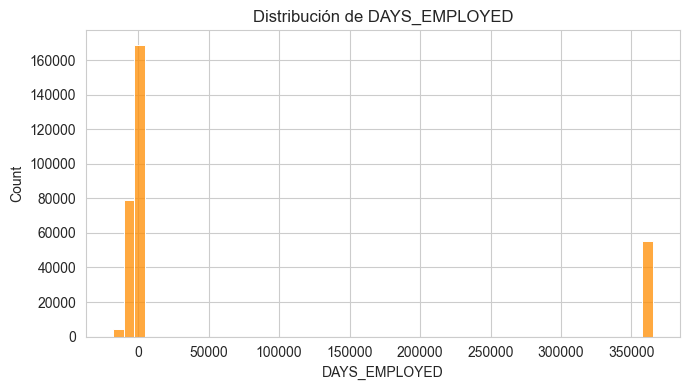

Filas con DAYS_EMPLOYED = 365243: 55374 (18.0%)
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(train["DAYS_EMPLOYED"], bins=50, ax=ax, color="darkorange")
ax.set_title("Distribución de DAYS_EMPLOYED")
plt.tight_layout()
plt.show()

anomalo = train["DAYS_EMPLOYED"] == 365243
print(f"Filas con DAYS_EMPLOYED = 365243: {anomalo.sum()} ({anomalo.mean()*100:.1f}%)")
print(train.loc[anomalo, "NAME_INCOME_TYPE"].value_counts())

El histograma muestra una concentración anómala de valores en 365,243 días (equivalentes a aproximadamente mil años), lo cual es evidentemente inválido. Este valor está presente en el 18% de las observaciones y corresponde casi en su totalidad a clientes clasificados como Pensioner o Unemployed. Se interpreta como un valor centinela usado por el dataset original para representar "sin empleo actual", y se tratará como dato faltante en la limpieza.

### 1.6 Edad del cliente

DAYS_BIRTH expresa la edad en días negativos respecto a la fecha de solicitud. Se transforma a años para facilitar su interpretación.

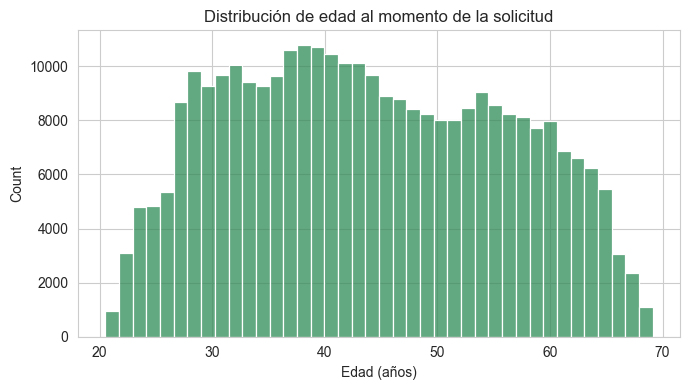

count    307511.0
mean         43.9
std          12.0
min          20.5
25%          34.0
50%          43.2
75%          53.9
max          69.1
Name: DAYS_BIRTH, dtype: float64


In [14]:
edad_anios = -train["DAYS_BIRTH"] / 365

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(edad_anios, bins=40, ax=ax, color="seagreen")
ax.set_title("Distribución de edad al momento de la solicitud")
ax.set_xlabel("Edad (años)")
plt.tight_layout()
plt.show()

print(edad_anios.describe().round(1))

La distribución de edad es razonable, sin valores fuera de un rango plausible (20 a 69 años aproximadamente), por lo que no requiere tratamiento adicional.

### 1.7 Variables categóricas del perfil socioeconómico

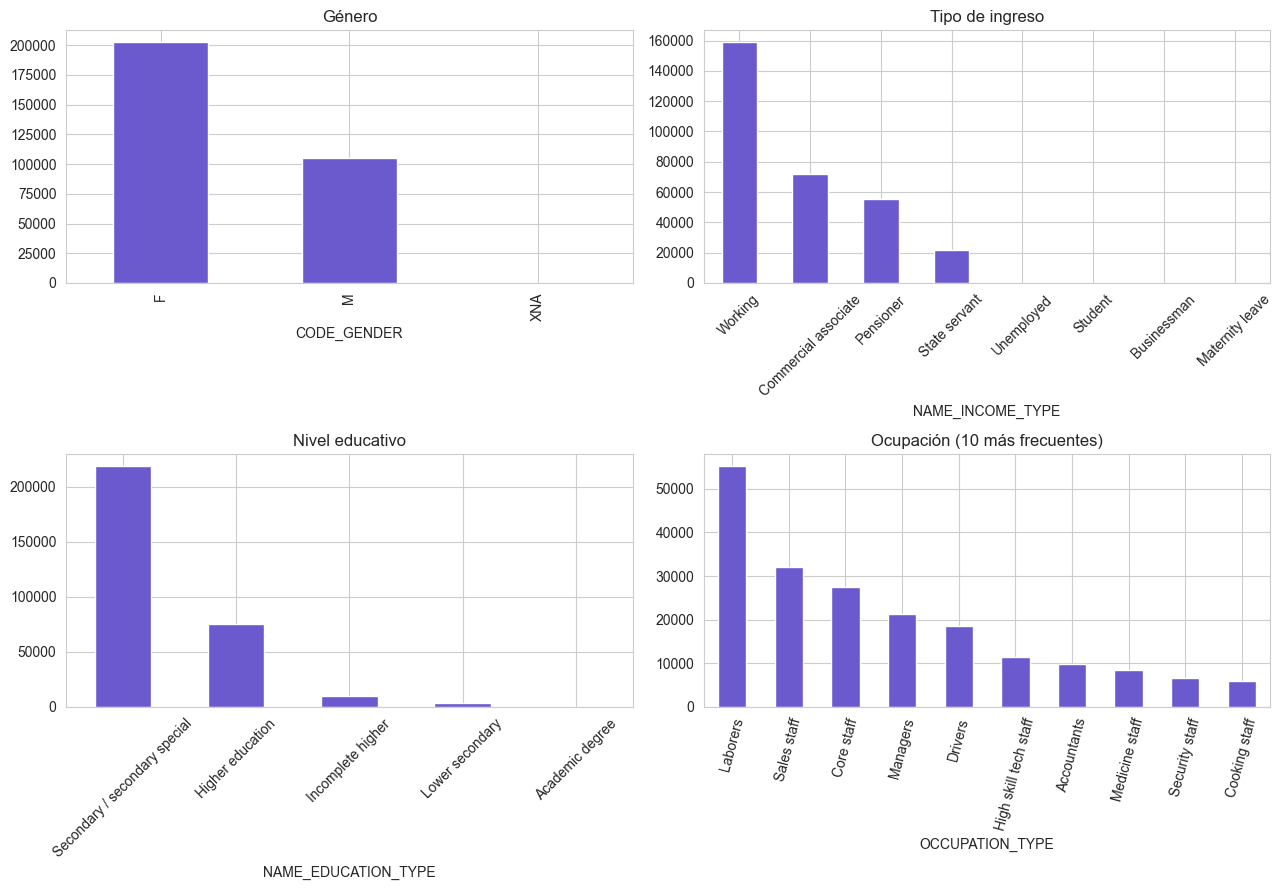

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

train["CODE_GENDER"].value_counts().plot(kind="bar", ax=axes[0, 0], color="slateblue")
axes[0, 0].set_title("Género")

train["NAME_INCOME_TYPE"].value_counts().plot(kind="bar", ax=axes[0, 1], color="slateblue")
axes[0, 1].set_title("Tipo de ingreso")
axes[0, 1].tick_params(axis="x", rotation=45)

train["NAME_EDUCATION_TYPE"].value_counts().plot(kind="bar", ax=axes[1, 0], color="slateblue")
axes[1, 0].set_title("Nivel educativo")
axes[1, 0].tick_params(axis="x", rotation=45)

train["OCCUPATION_TYPE"].value_counts().head(10).plot(kind="bar", ax=axes[1, 1], color="slateblue")
axes[1, 1].set_title("Ocupación (10 más frecuentes)")
axes[1, 1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

print(train["CODE_GENDER"].value_counts())

In [16]:
xna_org = (train["ORGANIZATION_TYPE"] == "XNA").sum()
print(f"ORGANIZATION_TYPE = 'XNA': {xna_org} filas ({xna_org/len(train)*100:.1f}%)")

ORGANIZATION_TYPE = 'XNA': 55374 filas (18.0%)


CODE_GENDER presenta 4 registros con el valor "XNA", una cantidad marginal frente al total de la muestra. ORGANIZATION_TYPE presenta 55,374 registros con el mismo valor, cifra que coincide casi exactamente con el grupo de pensionados y desempleados identificado en la sección 1.5. Es consistente que estas personas no tengan una organización asociada, por lo que no se trata de un error de captura sino de una categoría legítima que conviene renombrar.

### 1.8 Poder predictivo de las variables de scoring externo

EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3 son puntajes normalizados provenientes de fuentes externas no especificadas por el proveedor del dataset. Se evalúa su relación lineal con la variable objetivo.

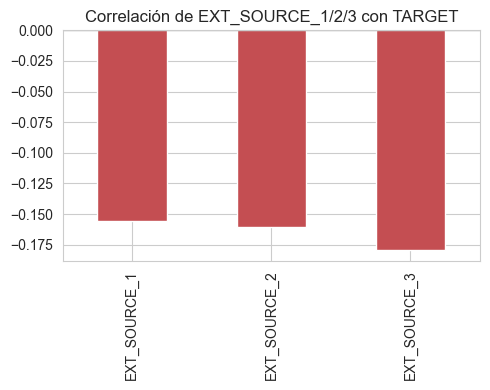

EXT_SOURCE_1   -0.155
EXT_SOURCE_2   -0.160
EXT_SOURCE_3   -0.179
Name: TARGET, dtype: float64


In [17]:
ext_corr = train[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "TARGET"]].corr()["TARGET"].drop("TARGET")

fig, ax = plt.subplots(figsize=(5, 4))
ext_corr.plot(kind="bar", ax=ax, color=["#C44E52" if v < 0 else "#4C72B0" for v in ext_corr])
ax.set_title("Correlación de EXT_SOURCE_1/2/3 con TARGET")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print(ext_corr.round(3))

Las tres variables presentan correlación negativa con TARGET: a mayor puntaje externo, menor probabilidad de incumplimiento. Son, en conjunto, las variables individuales más predictivas del dataset. Esto plantea una tensión relevante para el caso de negocio: el segmento de clientes sin historial en fuentes externas, justamente el segmento de interés para una fintech orientada a la inclusión financiera, carece de la señal más informativa del modelo, lo que exige reforzar el scoring con variables propias del cliente (ingreso declarado, ocupación, comportamiento de pago directo).

### 1.9 Historial crediticio externo (bureau.csv)

Se examina la tabla de historial crediticio en otras entidades, que complementa la información de application_train.

In [18]:
bureau.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


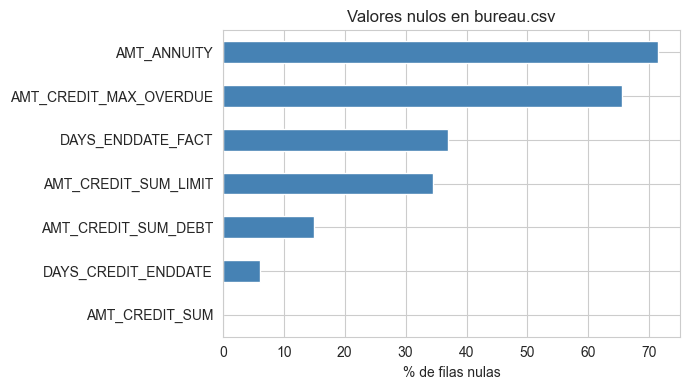

AMT_ANNUITY               71.5
AMT_CREDIT_MAX_OVERDUE    65.5
DAYS_ENDDATE_FACT         36.9
AMT_CREDIT_SUM_LIMIT      34.5
AMT_CREDIT_SUM_DEBT       15.0
DAYS_CREDIT_ENDDATE        6.1
AMT_CREDIT_SUM             0.0
dtype: float64

In [19]:
bureau_nulls = bureau.isnull().mean().sort_values(ascending=False) * 100
bureau_nulls = bureau_nulls[bureau_nulls > 0]

fig, ax = plt.subplots(figsize=(7, 4))
bureau_nulls.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% de filas nulas")
ax.set_title("Valores nulos en bureau.csv")
plt.tight_layout()
plt.show()

bureau_nulls.round(1)

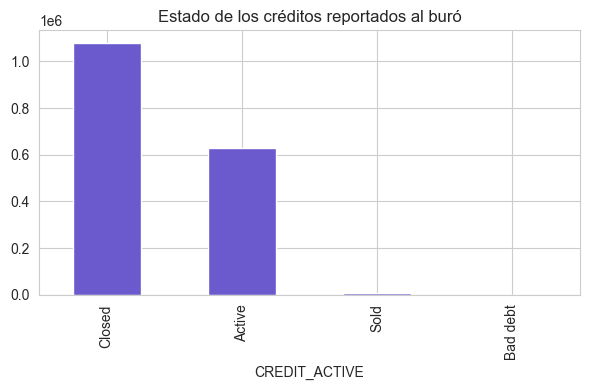

Filas con AMT_CREDIT_SUM_DEBT negativo: 8418


In [20]:
fig, ax = plt.subplots(figsize=(6, 4))
bureau["CREDIT_ACTIVE"].value_counts().plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Estado de los créditos reportados al buró")
plt.tight_layout()
plt.show()

neg_debt = (bureau["AMT_CREDIT_SUM_DEBT"] < 0).sum()
print(f"Filas con AMT_CREDIT_SUM_DEBT negativo: {neg_debt}")

Los nulos en montos como AMT_ANNUITY (71.5%) o AMT_CREDIT_MAX_OVERDUE (65.5%) son esperables, ya que no todos los créditos reportados incluyen esa información. Se identifican además 8,418 registros con deuda negativa en AMT_CREDIT_SUM_DEBT, posiblemente asociados a saldos a favor, que se marcarán como observación en la limpieza en lugar de eliminarse.

### 1.10 Cobertura de historial crediticio externo

Esta sección aborda el indicador central del caso de negocio: qué proporción de los clientes de application_train cuenta con historial en el buró de crédito.

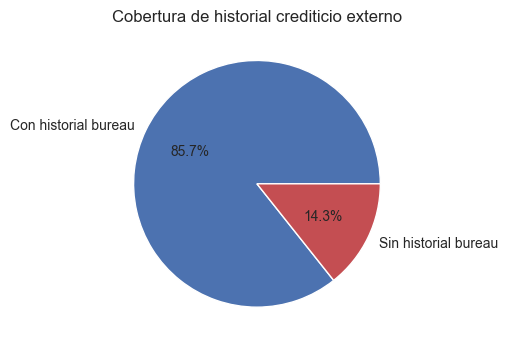

In [21]:
tiene_bureau = train["SK_ID_CURR"].isin(bureau["SK_ID_CURR"])

fig, ax = plt.subplots(figsize=(5, 5))
tiene_bureau.value_counts().rename({True: "Con historial bureau", False: "Sin historial bureau"}).plot(
    kind="pie", autopct="%1.1f%%", ax=ax, colors=["#4C72B0", "#C44E52"], ylabel=""
)
ax.set_title("Cobertura de historial crediticio externo")
plt.tight_layout()
plt.show()

El 85.7% de los clientes de application_train cuenta con historial crediticio externo, mientras que el 14.3% no lo tiene. Esto indica que el dataset representa mayoritariamente a una población con acceso previo al sistema financiero formal. La narrativa del caso de negocio, atención a clientes sin historial bancario tradicional, aplica de forma directa a ese 14.3%, lo cual conviene precisar en el informe para no sobredimensionar el alcance real del dataset respecto al segmento informal.

## Parte 2: Limpieza de datos

A partir de los hallazgos anteriores, se aplican las siguientes transformaciones sobre train y bureau.

### 2.1 Eliminación de variables descriptivas del edificio

Las columnas identificadas en la sección 1.2 (variantes _AVG, _MODE y _MEDI de las características del edificio, junto con FONDKAPREMONT_MODE, HOUSETYPE_MODE, TOTALAREA_MODE, WALLSMATERIAL_MODE y EMERGENCYSTATE_MODE) se eliminan del dataset de trabajo por su alta proporción de nulos y su relevancia secundaria para el caso de negocio. Estas columnas permanecen disponibles en la capa raw de la base de datos.

In [22]:
building_cols = [c for c in train.columns if c.endswith(("_AVG", "_MODE", "_MEDI"))]
building_cols += ["FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "TOTALAREA_MODE",
                   "WALLSMATERIAL_MODE", "EMERGENCYSTATE_MODE"]
building_cols = [c for c in set(building_cols) if c in train.columns]

print(f"Columnas eliminadas: {len(building_cols)}")
train = train.drop(columns=building_cols)
print("Nueva forma del dataset:", train.shape)

Columnas eliminadas: 47
Nueva forma del dataset: (307511, 75)


### 2.2 Tratamiento de EXT_SOURCE_1/2/3

Dado que estas variables concentran gran parte del poder predictivo del modelo (sección 1.8), no se imputan con la media, ya que esto eliminaría la señal asociada a la ausencia de historial externo. En su lugar, se crean indicadores binarios de disponibilidad y se conserva el valor faltante como tal, aprovechando que los algoritmos basados en árboles (XGBoost, LightGBM) manejan valores nulos de forma nativa.

In [23]:
for col in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]:
    train[f"TIENE_{col}"] = train[col].notna().astype(int)

train[["EXT_SOURCE_1", "TIENE_EXT_SOURCE_1", "EXT_SOURCE_2", "TIENE_EXT_SOURCE_2"]].head()

,EXT_SOURCE_1,TIENE_EXT_SOURCE_1,EXT_SOURCE_2,TIENE_EXT_SOURCE_2
0,0.083037,1,0.262949,1
1,0.311267,1,0.622246,1
2,NaN,0,0.555912,1
3,NaN,0,0.650442,1
4,NaN,0,0.322738,1


### 2.3 Corrección de DAYS_EMPLOYED

Se reemplaza el valor centinela identificado en la sección 1.5 (365,243) por un valor nulo, y se agrega un indicador binario que preserva la información de que el cliente no reporta empleo actual.

In [24]:
train["DAYS_EMPLOYED_ANOM"] = (train["DAYS_EMPLOYED"] == 365243).astype(int)
train.loc[train["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan

print("Registros marcados como anómalos:", train["DAYS_EMPLOYED_ANOM"].sum())
print("Valores nulos en DAYS_EMPLOYED tras la corrección:", train["DAYS_EMPLOYED"].isna().sum())

Registros marcados como anómalos: 55374
Valores nulos en DAYS_EMPLOYED tras la corrección: 55374


Este tratamiento coincide con el aplicado en el notebook de referencia consultado (home-credit-risk-portfolio-strategy-python-sql.ipynb), que también reemplaza el valor 365243 por nulo. La diferencia es que aquí se agrega además el indicador DAYS_EMPLOYED_ANOM para no perder la señal de que se trataba de un valor centinela y no de un dato faltante genuino.

### 2.4 Registros con género no especificado

Los 4 registros con CODE_GENDER = "XNA" (sección 1.7) se eliminan del dataset por representar una fracción despreciable del total.

In [25]:
antes = len(train)
train = train[train["CODE_GENDER"] != "XNA"]
print(f"Registros eliminados: {antes - len(train)}")

Registros eliminados: 4


### 2.5 Recategorización de ORGANIZATION_TYPE

El valor "XNA" (sección 1.7) se reemplaza por una etiqueta explícita, ya que corresponde a una categoría válida (clientes sin organización asociada) y no a un dato faltante.

In [26]:
train["ORGANIZATION_TYPE"] = train["ORGANIZATION_TYPE"].replace("XNA", "Sin organización")
train["ORGANIZATION_TYPE"].value_counts().head(5)

ORGANIZATION_TYPE
Business Entity Type 3    67992
Sin organización          55374
Self-employed             38412
Other                     16683
Medicine                  11192
Name: count, dtype: int64

### 2.6 Imputación de OCCUPATION_TYPE y demás categóricas con nulos residuales

OCCUPATION_TYPE (31.4% de nulos, sección 1.2) no forma parte del bloque de variables del edificio y sí es relevante para el caso de negocio, por lo que requiere tratamiento propio en lugar de descartarse. Se imputa con una categoría explícita en vez de eliminarse, siguiendo el mismo criterio aplicado a ORGANIZATION_TYPE: la ausencia de ocupación registrada es informativa (coincide en gran medida con clientes pensionados o sin organización asociada), no un error de captura.

Se aplica el mismo criterio a NAME_TYPE_SUITE (0.4% de nulos), cuya proporción es marginal.

In [27]:
train["OCCUPATION_TYPE"] = train["OCCUPATION_TYPE"].fillna("Sin especificar")
train["NAME_TYPE_SUITE"] = train["NAME_TYPE_SUITE"].fillna("Sin especificar")

print("Nulos restantes en OCCUPATION_TYPE:", train["OCCUPATION_TYPE"].isna().sum())
print("Nulos restantes en NAME_TYPE_SUITE:", train["NAME_TYPE_SUITE"].isna().sum())

Nulos restantes en OCCUPATION_TYPE: 0
Nulos restantes en NAME_TYPE_SUITE: 0


### 2.7 Consultas al buró de crédito (AMT_REQ_CREDIT_BUREAU_*)

Las seis variables AMT_REQ_CREDIT_BUREAU_* comparten 13.5% de nulos cada una (sección 1.2), lo que indica que faltan de forma conjunta en las mismas filas. Se asume que la ausencia de valor corresponde a clientes sin consultas registradas al buró en esa ventana de tiempo, y se imputan con 0. Esta es una interpretación razonable dado el contexto de la variable, no un hecho confirmado por la documentación del dataset.

In [28]:
req_cols = ["AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY", "AMT_REQ_CREDIT_BUREAU_WEEK",
            "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR"]

train[req_cols] = train[req_cols].fillna(0)
train[req_cols].isna().sum()

AMT_REQ_CREDIT_BUREAU_HOUR    0
AMT_REQ_CREDIT_BUREAU_DAY     0
AMT_REQ_CREDIT_BUREAU_WEEK    0
AMT_REQ_CREDIT_BUREAU_MON     0
AMT_REQ_CREDIT_BUREAU_QRT     0
AMT_REQ_CREDIT_BUREAU_YEAR    0
dtype: int64

### 2.8 Variables numéricas con nulos residuales menores a 1%

AMT_ANNUITY, AMT_GOODS_PRICE, CNT_FAM_MEMBERS, DAYS_LAST_PHONE_CHANGE y las cuatro variables de círculo social (OBS_30/60_CNT_SOCIAL_CIRCLE, DEF_30/60_CNT_SOCIAL_CIRCLE) tienen una proporción de nulos inferior al 1% (entre 1 y 1,021 registros según la columna). Dado el volumen marginal, se imputan con la mediana de cada columna, lo cual tiene un efecto prácticamente nulo sobre la distribución general.

In [29]:
cols_mediana = ["AMT_ANNUITY", "AMT_GOODS_PRICE", "CNT_FAM_MEMBERS", "DAYS_LAST_PHONE_CHANGE",
                "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
                "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"]

for col in cols_mediana:
    train[col] = train[col].fillna(train[col].median())

train[cols_mediana].isna().sum()

AMT_ANNUITY                 0
AMT_GOODS_PRICE             0
CNT_FAM_MEMBERS             0
DAYS_LAST_PHONE_CHANGE      0
OBS_30_CNT_SOCIAL_CIRCLE    0
DEF_30_CNT_SOCIAL_CIRCLE    0
OBS_60_CNT_SOCIAL_CIRCLE    0
DEF_60_CNT_SOCIAL_CIRCLE    0
dtype: int64

### 2.9 OWN_CAR_AGE: nulo estructural, sin imputación

OWN_CAR_AGE tiene 66% de nulos (sección 1.2), pero a diferencia de los casos anteriores, aquí la ausencia de valor no es un dato faltante en el sentido convencional: corresponde a clientes que no poseen automóvil, información que ya está capturada explícitamente en FLAG_OWN_CAR. Imputar una antigüedad de vehículo a quien no tiene vehículo introduciría un valor ficticio sin sustento, por lo que la columna se deja sin modificar; el nulo debe interpretarse en conjunto con FLAG_OWN_CAR.

In [30]:
print(pd.crosstab(train["FLAG_OWN_CAR"], train["OWN_CAR_AGE"].isna(), rownames=["FLAG_OWN_CAR"], colnames=["OWN_CAR_AGE es nulo"]))

OWN_CAR_AGE es nulo   False   True 
FLAG_OWN_CAR                       
N                         0  202922
Y                    104580       5


### 2.10 Tratamiento del valor atípico en AMT_INCOME_TOTAL

Se aplica winsorización al percentil 99 sobre el ingreso declarado, acotando el efecto del valor extremo identificado en la sección 1.4 sin descartar el registro completo.

Al revisar un notebook de referencia sobre el mismo dataset (home-credit-risk-portfolio-strategy-python-sql.ipynb), se observó un tratamiento alternativo para esta misma variable: excluir directamente las filas con ingreso declarado superior a 2.5 millones. Ambas estrategias son razonables; se optó aquí por la winsorización porque preserva el total de registros del dataset, a costa de introducir una pequeña concentración artificial de valores exactamente en el percentil 99. La alternativa de exclusión evita esa concentración pero reduce el tamaño de la muestra. Dado que la cantidad de filas afectadas es pequeña en ambos casos, la elección no debería tener un impacto relevante sobre el modelo final.

In [31]:
cap = train["AMT_INCOME_TOTAL"].quantile(0.99)
n_capped = (train["AMT_INCOME_TOTAL"] > cap).sum()
train["AMT_INCOME_TOTAL"] = train["AMT_INCOME_TOTAL"].clip(upper=cap)

print(f"Registros acotados al percentil 99 ({cap:,.0f}): {n_capped}")
print(train["AMT_INCOME_TOTAL"].describe())

Registros acotados al percentil 99 (472,500): 3014
count    307507.000000
mean     166025.652765
std       83063.826418
min       25650.000000
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      472500.000000
Name: AMT_INCOME_TOTAL, dtype: float64


### 2.11 NAME_INCOME_TYPE: se conservan las categorías minoritarias

El mismo notebook de referencia filtra NAME_INCOME_TYPE para conservar únicamente las categorías Working, Commercial associate, Pensioner y State servant, descartando Unemployed, Student, Businessman y Maternity leave por su bajo volumen (55 registros en conjunto, sobre 307 mil).

En este proyecto se decide conservar esas categorías minoritarias. El caso de negocio de CrediFácil está orientado a clientes con perfiles de ingreso no tradicionales, por lo que descartar justamente esos segmentos iría en contra del objetivo de inclusión financiera planteado. El bajo volumen de estas categorías se documenta como limitación (no permiten conclusiones estadísticamente robustas por sí solas), pero no se eliminan.

In [32]:
train["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158771
Commercial associate     71616
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

### 2.12 Marcado de deuda negativa en bureau.csv

Los registros con AMT_CREDIT_SUM_DEBT negativo (sección 1.9) se conservan y se marcan con un indicador, en lugar de eliminarse, dado que su validez requiere confirmación adicional antes de descartar información.

In [33]:
bureau["DEBT_NEGATIVA_FLAG"] = (bureau["AMT_CREDIT_SUM_DEBT"] < 0).astype(int)
print("Registros marcados:", bureau["DEBT_NEGATIVA_FLAG"].sum())
bureau.loc[bureau["DEBT_NEGATIVA_FLAG"] == 1, ["SK_ID_CURR", "AMT_CREDIT_SUM_DEBT", "CREDIT_ACTIVE"]].head()

Registros marcados: 8418


,SK_ID_CURR,AMT_CREDIT_SUM_DEBT,CREDIT_ACTIVE
21,222183,-411.615,Active
87,119939,-2692.170,Closed
88,119939,-149.040,Closed
89,119939,-2.565,Active
125,293201,-701.280,Closed


### 2.13 Construcción del indicador de historial crediticio

Se construye la variable TIENE_HISTORIAL_BUREAU, correspondiente al cruce descrito en la sección 1.10 y central para el indicador de inclusión financiera del proyecto.

In [34]:
train["TIENE_HISTORIAL_BUREAU"] = train["SK_ID_CURR"].isin(bureau["SK_ID_CURR"]).astype(int)
train["TIENE_HISTORIAL_BUREAU"].value_counts(normalize=True).round(3)

TIENE_HISTORIAL_BUREAU
1    0.857
0    0.143
Name: proportion, dtype: float64

### 2.14 Desbalance de clases

El desbalance descrito en la sección 1.3 no requiere ninguna transformación sobre los datos, pero se documenta como consideración para la etapa de modelamiento: se recomienda ponderar las clases durante el entrenamiento y evaluar el desempeño con AUC-ROC.

### 2.15 Verificación final de nulos

Se confirma que, tras la limpieza, únicamente quedan valores nulos en las columnas donde la ausencia de dato es intencional y está documentada: las variables EXT_SOURCE_1/2/3 (sección 2.2), DAYS_EMPLOYED (sección 2.3) y OWN_CAR_AGE (sección 2.9).

In [35]:
nulos_finales = train.isnull().mean().sort_values(ascending=False) * 100
nulos_finales[nulos_finales > 0].round(2)

OWN_CAR_AGE      65.99
EXT_SOURCE_1     56.38
EXT_SOURCE_3     19.83
DAYS_EMPLOYED    18.01
EXT_SOURCE_2      0.21
dtype: float64

## 3. Exportación de los datos limpios

Los datasets resultantes se guardan en ../dataset/, listos para ser cargados al pipeline hacia la base de datos (pipeline/load_raw.py) o utilizados directamente en la etapa de modelamiento.

In [36]:
import os
os.makedirs("../dataset", exist_ok=True)

train.to_csv("../dataset/application_train_clean.csv", index=False)
bureau.to_csv("../dataset/bureau_clean.csv", index=False)

print("application_train_clean.csv:", train.shape)
print("bureau_clean.csv:", bureau.shape)

application_train_clean.csv: (307507, 80)
bureau_clean.csv: (1716428, 18)
